<a href="https://colab.research.google.com/github/Explicable11/Digital-Twin-and-ML-for-Cardiovascular-Diseases/blob/main/Heart_Disease_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Project Title*** = "AI-Driven Patient Digital Twin for Heart Disease Prediction" *italicized text*

***Project Description*** = "Analyzing heart disease indicators and linking them to AI-driven personalized healthcare concepts from digital twin research."

***Dataset Name*** = "Heart Disease Dataset (UCI Repository)"

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Define file path for your heart disease dataset
csv_path = '/content/drive/MyDrive/heart_disease_uci.csv'

# Load the CSV file
df = pd.read_csv(csv_path)

# --- MODIFIED FOR 2-CLASS CLASSIFICATION (HEART DISEASE) ---
# The 'num' column is commonly used as the target in UCI heart datasets
# Convert it into binary: 0 = No Heart Disease, 1 = Heart Disease Present (1–4)
def assign_class(value):
    return 0 if value == 0 else 1

df['heart_disease_class'] = df['num'].apply(assign_class)

# Display the first few rows and the binary class distribution
print("✅ Dataset Head with Binary Classes:")
print(df.head())

print("\n✅ Binary Class Distribution:")
print(df['heart_disease_class'].value_counts())


✅ Dataset Head with Binary Classes:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  heart_disease_class  
0       fixed defect    0                    0  
1             normal    2                 

In [ ]:
# Dataset summary
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nData Types:\n", df.dtypes)

# Display random sample
df.sample(5)


Number of Rows: 920
Number of Columns: 17

Data Types:
 id                       int64
age                      int64
sex                     object
dataset                 object
cp                      object
trestbps               float64
chol                   float64
fbs                     object
restecg                 object
thalch                 float64
exang                   object
oldpeak                float64
slope                   object
ca                     float64
thal                    object
num                      int64
heart_disease_class      int64
dtype: object


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,heart_disease_class
495,496,36,Male,Hungary,atypical angina,120.0,267.0,False,normal,160.0,False,3.0,flat,NaN,NaN,1,1
645,646,54,Male,Switzerland,asymptomatic,120.0,0.0,False,normal,155.0,False,0.0,flat,NaN,reversable defect,2,1
243,244,61,Male,Cleveland,typical angina,134.0,234.0,False,normal,145.0,False,2.6,flat,2.0,normal,2,1
654,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,2,1
530,531,39,Male,Hungary,asymptomatic,110.0,280.0,False,normal,150.0,False,0.0,NaN,NaN,fixed defect,1,1



📊 Numerical Summary Table:

                       Mean  Median   Mode   Min    Max  Range     Std
id                   460.50   460.5    1.0   1.0  920.0  919.0  265.73
age                   53.51    54.0   54.0  28.0   77.0   49.0    9.42
trestbps             132.13   130.0  120.0   0.0  200.0  200.0   19.07
chol                 199.13   223.0    0.0   0.0  603.0  603.0  110.78
thalch               137.55   140.0  150.0  60.0  202.0  142.0   25.93
oldpeak                0.88     0.5    0.0  -2.6    6.2    8.8    1.09
ca                     0.68     0.0    0.0   0.0    3.0    3.0    0.94
num                    1.00     1.0    0.0   0.0    4.0    4.0    1.14
heart_disease_class    0.55     1.0    1.0   0.0    1.0    1.0    0.50


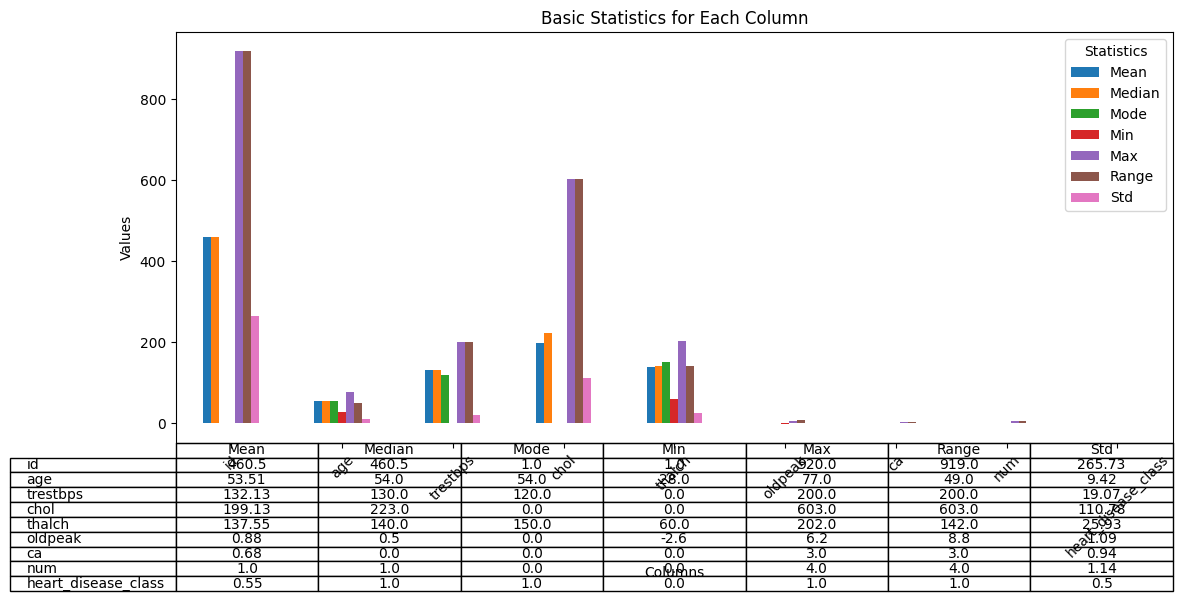

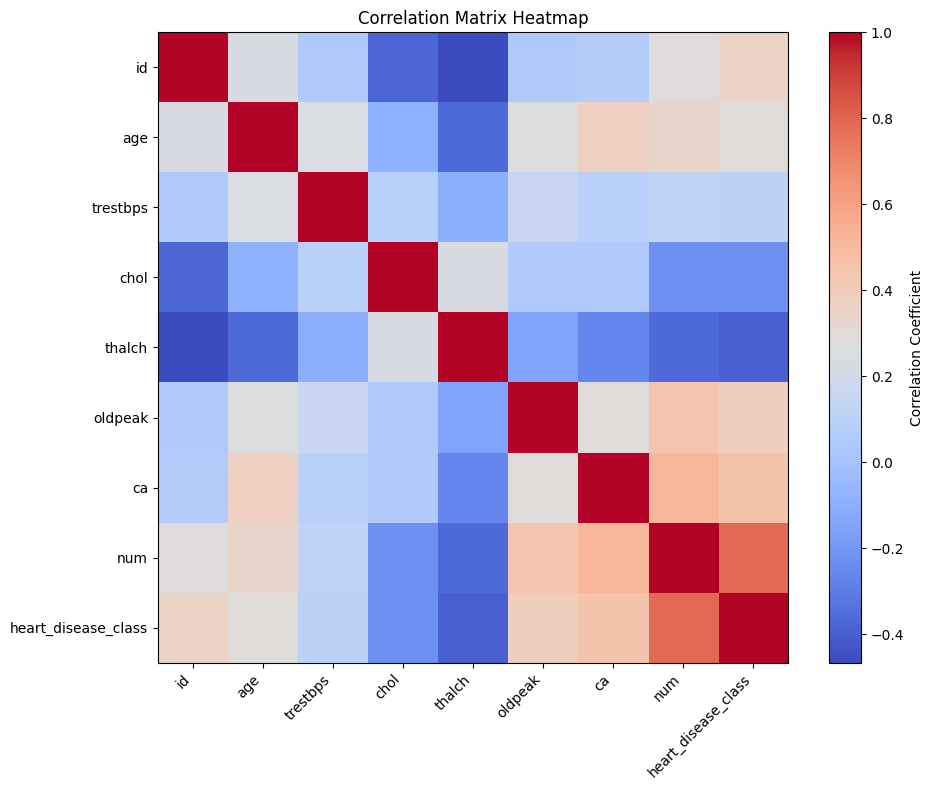

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Example: Assuming df is already loaded ===

# --- BASIC STATISTICS ---
mean_vals = df.mean(numeric_only=True)
median_vals = df.median(numeric_only=True)
mode_vals = df.mode(numeric_only=True).iloc[0]
min_vals = df.min(numeric_only=True)
max_vals = df.max(numeric_only=True)
range_vals = max_vals - min_vals
std_vals = df.std(numeric_only=True)

# Combine into a single DataFrame for plotting
stats_df = pd.DataFrame({
    'Mean': mean_vals,
    'Median': median_vals,
    'Mode': mode_vals,
    'Min': min_vals,
    'Max': max_vals,
    'Range': range_vals,
    'Std': std_vals
})

# -------- OPTION 1: Print in console (Pandas table) --------
print("\n📊 Numerical Summary Table:\n")
print(stats_df.round(2))   # rounded for readability

# -------- OPTION 2: Show inside Matplotlib plot --------
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bar chart
stats_df.plot(kind='bar', ax=ax)
ax.set_title("Basic Statistics for Each Column")
ax.set_xlabel("Columns")
ax.set_ylabel("Values")
plt.xticks(rotation=45)
plt.legend(title="Statistics")

# Add table below the plot
plt.table(
    cellText=stats_df.round(2).values,
    rowLabels=stats_df.index,
    colLabels=stats_df.columns,
    cellLoc="center",
    loc="bottom"
)

plt.subplots_adjust(left=0.2, bottom=0.35)  # space for table
plt.tight_layout()
plt.show()

# --- CORRELATION DIAGRAM (HEATMAP) ---
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation Coefficient")

# Add labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


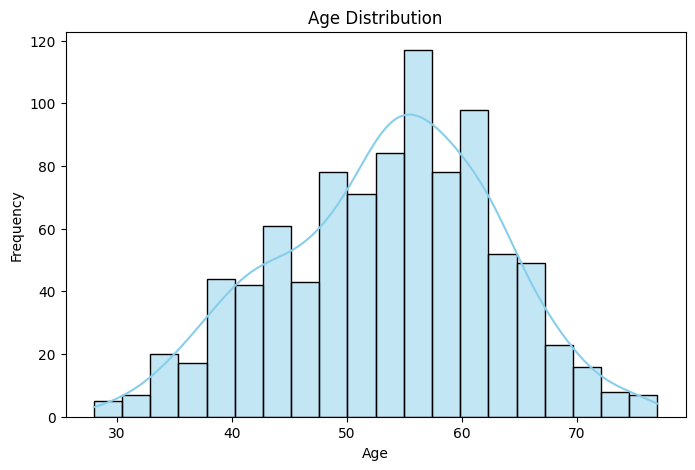

/tmp/ipython-input-409831114.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cp', data=df, palette='viridis')


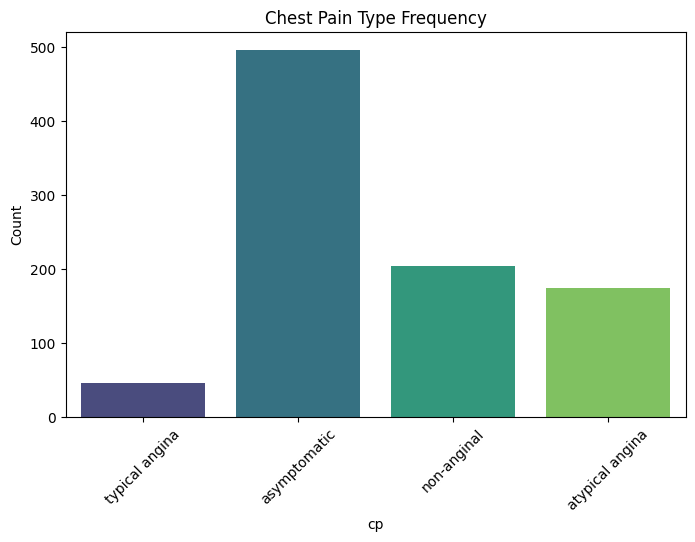

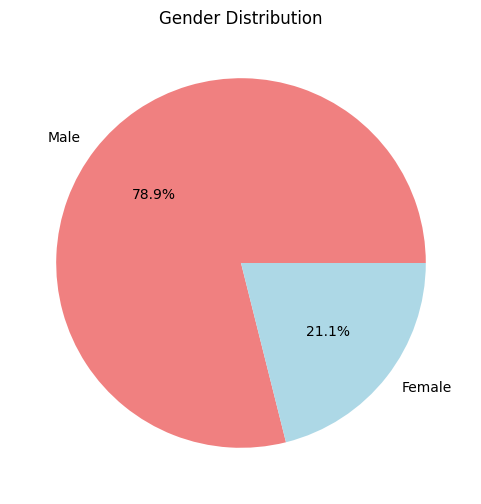

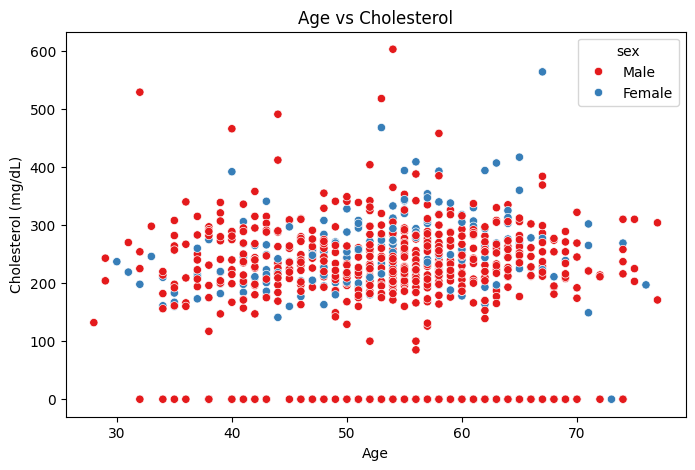

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogram: Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 2. Bar Chart: Chest Pain Type frequency
plt.figure(figsize=(8,5))
sns.countplot(x='cp', data=df, palette='viridis')
plt.title('Chest Pain Type Frequency')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# 3. Pie Chart: Gender proportion
plt.figure(figsize=(6,6))
df['sex'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral','lightblue'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


# 5. Scatter Plot: Age vs Cholesterol
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='chol', hue='sex', data=df, palette='Set1')
plt.title('Age vs Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol (mg/dL)')
plt.show()


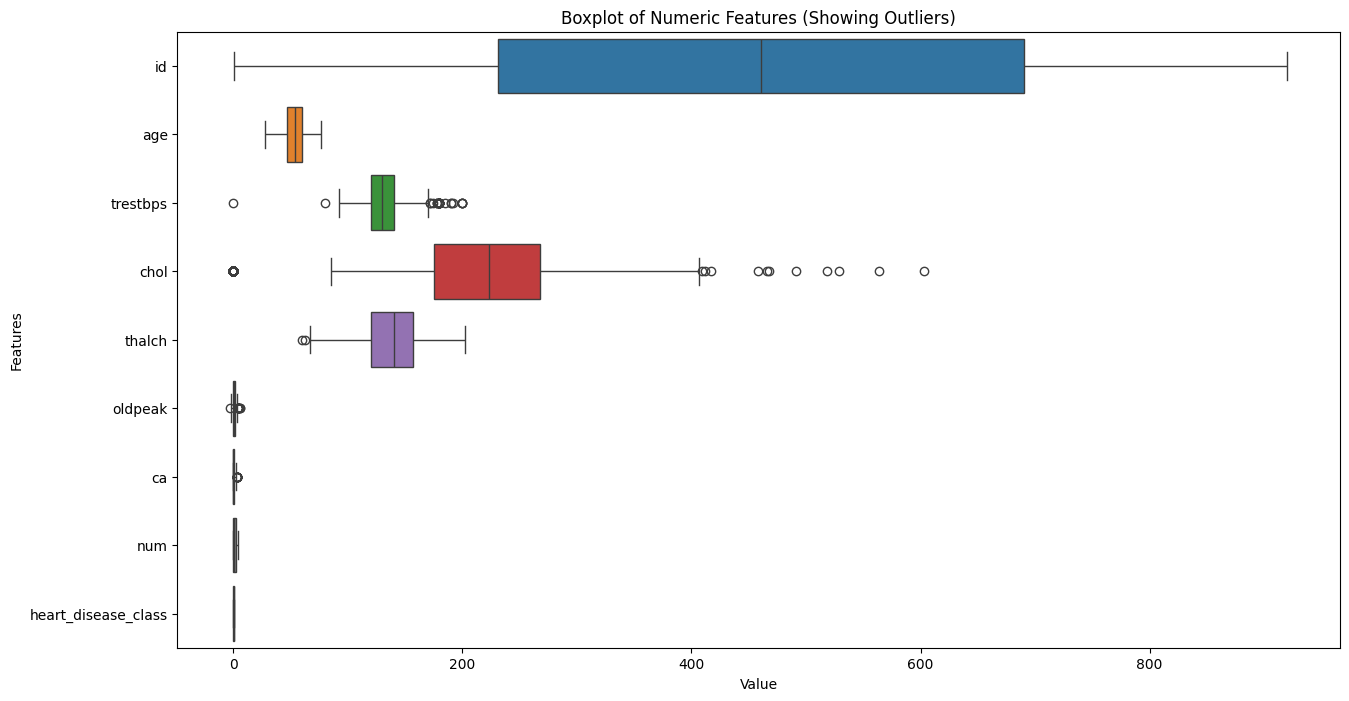

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
csv_path = '/content/drive/MyDrive/heart_disease_uci.csv'
df = pd.read_csv(csv_path)

# Convert 'num' to binary heart disease class
df['heart_disease_class'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

# Select numeric columns for boxplot
numeric_cols = df.select_dtypes(include='number').columns

# Plot boxplots for each numeric column
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplot of Numeric Features (Showing Outliers)")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()


In [ ]:
print("\n=== KEY FINDINGS ===")
print(f"1. Majority of patients are aged between {int(df['age'].quantile(0.25))} and {int(df['age'].quantile(0.75))} years.")
print("2. 'Asymptomatic' chest pain type is the most frequent category.")
print(f"3. Male patients dominate the dataset ({df['sex'].value_counts().idxmax()}).")
print(f"4. Cholesterol levels have significant outliers above {int(df['chol'].quantile(0.95))} mg/dL.")



=== KEY FINDINGS ===
1. Majority of patients are aged between 47 and 60 years.
2. 'Asymptomatic' chest pain type is the most frequent category.
3. Male patients dominate the dataset (Male).
4. Cholesterol levels have significant outliers above 334 mg/dL.


First, we need to set up our environment by importing the necessary libraries for data manipulation, visualization, and machine learning. Then, we'll upload the heart_disease_uci (1).csv file to our Colab environment and load it into a pandas DataFrame.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# For modeling
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB # Using as a probabilistic baseline

# For evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set visualization style
sns.set_style('whitegrid')

# Step 2 — Upload dataset
Upload the CSV file `heart_disease_uci.csv` (use Colab file upload or mount Drive). The code will try common locations first.


In [ ]:
# Step 2 — Load dataset
possible_paths = [
   '/content/drive/MyDrive/heart_disease_uci.csv'
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    from google.colab import files
    print("Please upload `heart_disease_uci.csv` now (browser file upload will open).")
    uploaded = files.upload()
    data_path = list(uploaded.keys())[0]

print("Loading:", data_path)
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Loading: /content/drive/MyDrive/heart_disease_uci.csv
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# **STEP 3**
Data Cleaning and Preprocessing

This is the most critical step. The quality of our model depends heavily on the quality of our data. We will perform the following actions:

Inspect Data: Check for missing values, data types, and basic statistics.

Handle Missing Values: The dataset is known to use '?' as a placeholder for missing data. We'll replace these with NaN and then impute them using a suitable strategy (e.g., the median for numerical columns).

Correct Data Types: Ensure all columns have the correct data type (e.g., numeric columns are float or int).

Create Target Variable: The num column indicates the severity of heart disease (0 = no disease, 1-4 = varying degrees of disease). We will convert this into a binary target variable target where 0 means no disease and 1 means disease is present.

In [ ]:
# Get a summary of the dataframe
print("Dataset Information:")
df.info()

# Replace '?' with NaN (Not a Number) to handle missing values properly
df.replace('?', np.nan, inplace=True)

# Convert columns with potential missing values to numeric, coercing errors
for col in ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'thal']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for missing values again
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Create the binary target variable
# 0 = No heart disease, 1 = Presence of heart disease
df['target'] = (df['num'] > 0).astype(int)

# Drop the original 'id' and 'num' columns as they are no longer needed
df.drop(['id', 'num'], axis=1, inplace=True)

print("\nDataset shape after creating target variable:", df.shape)
print("\nFirst 5 rows with the new 'target' column:")
display(df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing values after cleaning:
id            0
age           0
sex           0
dataset       0
cp          

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,NaN,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,NaN,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,NaN,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,NaN,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,NaN,0


# **STEP 4**

Feature Engineering and Scaling

To prepare the data for our machine learning models, we need to handle categorical features and scale numerical features.

Identify Feature Types: We'll separate our columns into numerical and categorical lists.

Create Preprocessing Pipelines:

For numerical features, we will first impute any missing values with the median and then scale them using StandardScaler. Scaling ensures that all features contribute equally to the model's performance.

For categorical features, we will impute missing values with the most frequent value and then apply OneHotEncoder. This converts categories into a numerical format that the model can understand.

In [ ]:
# Separate features (X) from the target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identify numerical and categorical features
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Create a preprocessing pipeline for numerical features
# 1. Impute missing values with the median
# 2. Scale features to have zero mean and unit variance
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create a preprocessing pipeline for categorical features
# 1. Impute missing values with the most frequent value
# 2. One-Hot Encode the features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any)
)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (736, 14)
Testing set shape: (184, 14)


# **STEP 5**

Checking for Class Imbalance

Before we tune our models, it's important to see if our dataset is balanced

Target variable distribution:
target
1    509
0    411
Name: count, dtype: int64


/tmp/ipython-input-1664927045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


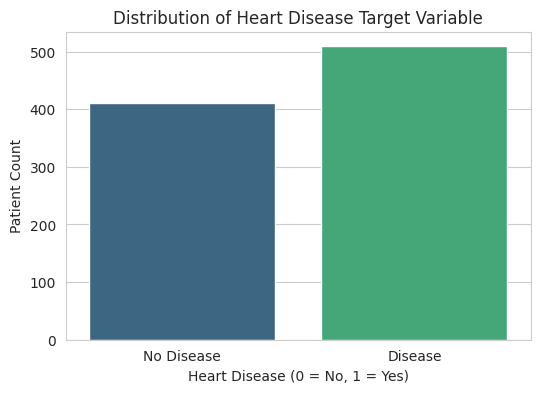

In [ ]:
# Check the distribution of the target variable
target_counts = df['target'].value_counts()
print("Target variable distribution:")
print(target_counts)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Heart Disease Target Variable')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()

# **STEP 6**

Model Training and Evaluation

Now we will train and evaluate our four selected models. For each model, we will:

Create a full pipeline that combines our preprocessor with the model.

Train the model on the training data (X_train, y_train).

Make predictions on the test data (X_test).

Evaluate the model using a classification report and a confusion matrix.

For the Bayesian model, we'll use Gaussian Naive Bayes. While not exactly Bayesian Logistic Regression, it's a strong probabilistic classifier based on Bayes' theorem and is readily available in scikit-learn.

1. Logistic Regression with Hyperparameter Tuning


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Best Parameters: {'classifier__C': 0.1, 'classifier__solver': 'saga'}
Best Cross-Validation Accuracy: 0.8315

Test Set Accuracy: 0.8424

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



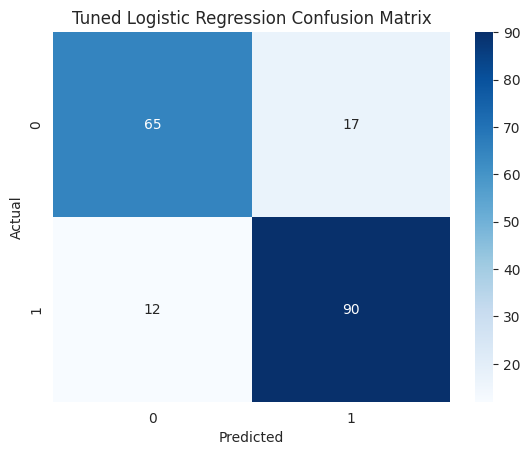


2. SVM with Hyperparameter Tuning


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Best Parameters: {'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8315

Test Set Accuracy: 0.8370

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.81        82
           1       0.82      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



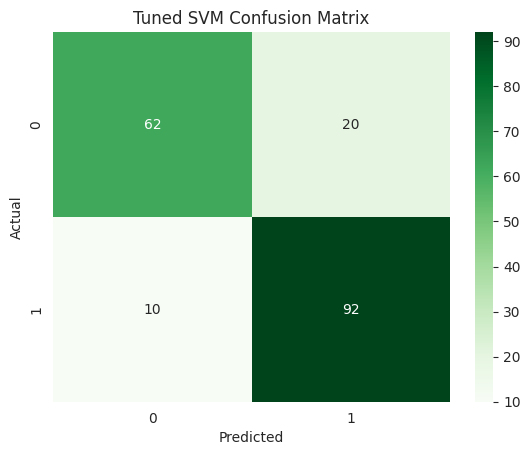


3. Random Forest with Hyperparameter Tuning


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best Cross-Validation Accuracy: 0.8220

Test Set Accuracy: 0.8587

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84        82
           1       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


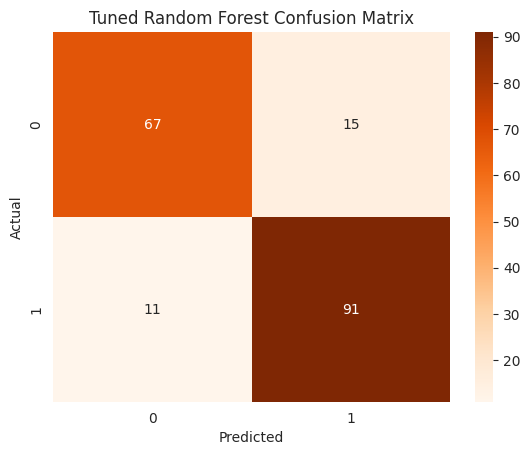


4. XGBoost Classifier
Test Set Accuracy: 0.8370

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:02:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


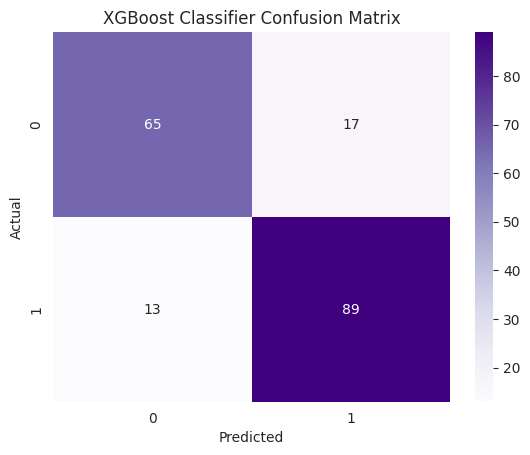


📊 Model Performance Summary
                 Model  Cross-Validation Accuracy  Test Accuracy
0  Logistic Regression                   0.831486       0.842391
1                  SVM                   0.831541       0.836957
2        Random Forest                   0.822017       0.858696
3              XGBoost                        NaN       0.836957


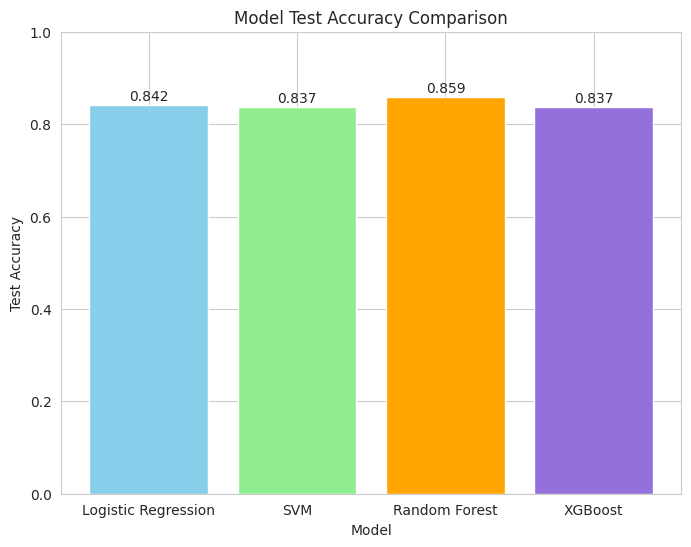

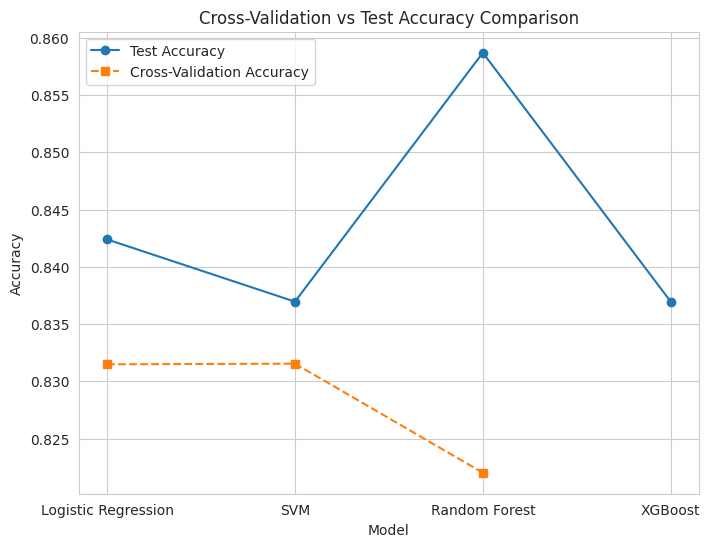

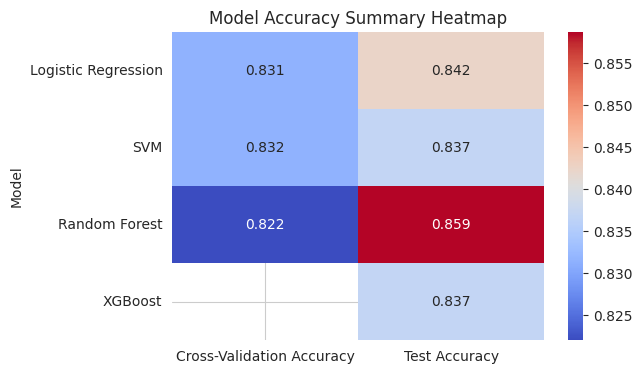

In [ ]:
# ===========================================
# Full Code: Model Training, Tuning & Graphical Comparison
# ===========================================

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Assuming these are already defined
# X_train, X_test, y_train, y_test, preprocessor

# --- Model 1: Logistic Regression with Hyperparameter Tuning ---
print("="*45)
print("1. Logistic Regression with Hyperparameter Tuning")
print("="*45)

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga']
}

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42, max_iter=2000))])

grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_lr.best_score_:.4f}")

best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# --- Model 2: SVM with Hyperparameter Tuning ---
print("\n" + "="*45)
print("2. SVM with Hyperparameter Tuning")
print("="*45)

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': [0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf']
}

svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', SVC(probability=True, random_state=42))])

grid_search_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_svm.best_score_:.4f}")

best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Tuned SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# --- Model 3: Random Forest with Hyperparameter Tuning ---
print("\n" + "="*45)
print("3. Random Forest with Hyperparameter Tuning")
print("="*45)

param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title('Tuned Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# --- Model 4: XGBoost Classifier ---
print("\n" + "="*45)
print("4. XGBoost Classifier")
print("="*45)

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost Classifier Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# ===========================================
# 📊 GRAPHICAL COMPARISON & SUMMARY
# ===========================================

# Collect model names and accuracies
model_names = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']
test_accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

cv_accuracies = [
    grid_search_lr.best_score_,
    grid_search_svm.best_score_,
    grid_search_rf.best_score_,
    None  # XGBoost didn't use GridSearchCV
]

# Create summary DataFrame
results_df = pd.DataFrame({
    'Model': model_names,
    'Cross-Validation Accuracy': cv_accuracies,
    'Test Accuracy': test_accuracies
})

print("\n" + "="*60)
print("📊 Model Performance Summary")
print("="*60)
print(results_df)

# --- Bar Plot for Model Comparison ---
plt.figure(figsize=(8,6))
plt.bar(model_names, test_accuracies, color=['skyblue', 'lightgreen', 'orange', 'mediumpurple'])
plt.title('Model Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
for i, acc in enumerate(test_accuracies):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center', fontsize=10)
plt.show()

# --- Line Plot for CV vs Test Accuracy ---
plt.figure(figsize=(8,6))
plt.plot(model_names, test_accuracies, marker='o', label='Test Accuracy')
plt.plot(model_names[:-1], cv_accuracies[:-1], marker='s', linestyle='--', label='Cross-Validation Accuracy')
plt.title('Cross-Validation vs Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Heatmap Summary ---
plt.figure(figsize=(6,4))
sns.heatmap(results_df.set_index('Model'), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Model Accuracy Summary Heatmap')
plt.show()


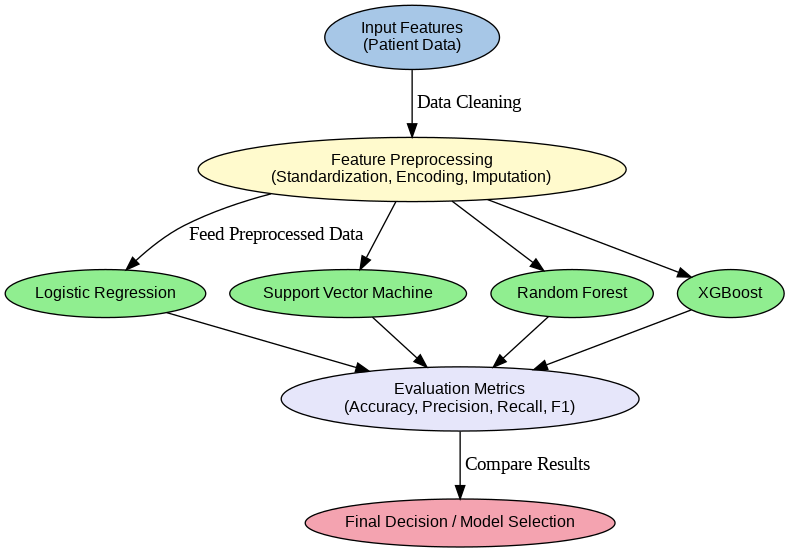

In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

# Create a graph for algorithm representation
algo_diagram = Digraph("Heart_Disease_Algorithm_Representation", format="png")
algo_diagram.attr(size='10,8')
algo_diagram.attr('node', shape='ellipse', style='filled', fontname="Arial", fontsize='12')

# Define color palette by component type
input_color = "#A7C7E7"      # blue tone for input
process_color = "#FFFACD"    # light yellow for processing
model_color = "#90EE90"      # green for models
output_color = "#F4A3B0"     # pink for results
metric_color = "#E6E6FA"     # lavender for metrics

# Input & Preprocessing
algo_diagram.node("input", "Input Features\n(Patient Data)", fillcolor=input_color)
algo_diagram.node("preprocess", "Feature Preprocessing\n(Standardization, Encoding, Imputation)", fillcolor=process_color)

# Core Algorithms (models)
algo_diagram.node("LR", "Logistic Regression", fillcolor=model_color)
algo_diagram.node("SVM", "Support Vector Machine", fillcolor=model_color)
algo_diagram.node("RF", "Random Forest", fillcolor=model_color)
algo_diagram.node("XGB", "XGBoost", fillcolor=model_color)

# Evaluation and Metrics
algo_diagram.node("metrics", "Evaluation Metrics\n(Accuracy, Precision, Recall, F1)", fillcolor=metric_color)
algo_diagram.node("output", "Final Decision / Model Selection", fillcolor=output_color)

# Connections (logic, not linear pipeline)
algo_diagram.edge("input", "preprocess", label=" Data Cleaning ")
algo_diagram.edge("preprocess", "LR", label=" Feed Preprocessed Data ")
algo_diagram.edge("preprocess", "SVM")
algo_diagram.edge("preprocess", "RF")
algo_diagram.edge("preprocess", "XGB")

# Models go to evaluation
algo_diagram.edge("LR", "metrics")
algo_diagram.edge("SVM", "metrics")
algo_diagram.edge("RF", "metrics")
algo_diagram.edge("XGB", "metrics")

# Final output based on best metrics
algo_diagram.edge("metrics", "output", label=" Compare Results ")

# Render and display inline
path = "/mnt/data/Heart_Disease_Algorithm_Graphical_Representation"
algo_diagram.render(path, cleanup=True)
display(Image(filename=f"{path}.png"))


🩺 Patient 20 Data Snapshot:


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca
19,61,Male,Switzerland,asymptomatic,160.0,0.0,True,st-t abnormality,145.0,False,1.0,flat,NaN



🧠 Digital Twin Prediction: Heart Disease
📊 Probability of Disease: 91.28%
--------------------------------------------------


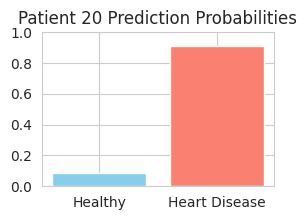


✅ Digital Twin Simulation Finished!


In [ ]:
# =========================================================
#  DIGITAL TWIN: HEART DISEASE PREDICTION SIMULATOR
#  Light & Colab-Friendly Version
# =========================================================

# ---- Imports ----
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# ---- Data Loading ----
data = pd.read_csv('/content/drive/MyDrive/heart_disease_uci.csv')  # Replace path as needed
data.replace('?', np.nan, inplace=True)

for col in ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'thal']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Create binary target variable
data['target'] = (data['num'] > 0).astype(int)
data.drop(['id', 'num'], axis=1, inplace=True)

# Drop thal if empty
if 'thal' in data.columns and data['thal'].isnull().all():
    data.drop('thal', axis=1, inplace=True)

# ---- Feature Split ----
X = data.drop('target', axis=1)
y = data['target']

# ---- Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Preprocessing ----
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

# ---- Pipeline with Random Forest ----
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42, n_estimators=200, n_jobs=-1, max_depth=8))
])

# ---- Train Model ----
dt_pipeline.fit(X_train, y_train)

# ---- Evaluate once ----
y_pred = dt_pipeline.predict(X_test)
print("✅ Model trained successfully!")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

# ---- Confusion Matrix ----
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =========================================================
# DIGITAL TWIN SIMULATION SECTION
# =========================================================

print("\n🔄 Starting Digital Twin Simulation...\n")

# Select a few random test samples to simulate incoming data
simulation_samples = X_test.sample(20, random_state=42).reset_index(drop=True)

for i in range(len(simulation_samples)):
    clear_output(wait=True)
    current_data = simulation_samples.iloc[[i]]  # keep DataFrame shape
    prediction = dt_pipeline.predict(current_data)[0]
    prob = dt_pipeline.predict_proba(current_data)[0][1]

    print(f"🩺 Patient {i+1} Data Snapshot:")
    display(current_data)
    print(f"\n🧠 Digital Twin Prediction: {'Heart Disease' if prediction==1 else 'Healthy'}")
    print(f"📊 Probability of Disease: {prob*100:.2f}%")
    print("--------------------------------------------------")

    # Lightweight progress visualization
    plt.figure(figsize=(3,2))
    plt.bar(['Healthy','Heart Disease'], dt_pipeline.predict_proba(current_data)[0], color=['skyblue','salmon'])
    plt.title(f"Patient {i+1} Prediction Probabilities")
    plt.ylim(0,1)
    plt.show()

    # Simulate a delay like real-time streaming
    time.sleep(1)

print("\n✅ Digital Twin Simulation Finished!")


In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

# Create a horizontal (landscape) but compact diagram
dt_graph_small = Digraph("Digital_Twin_Heart_Disease_Simulator_Small", format="png")
dt_graph_small.attr(rankdir='LR', size='10,5')  # smaller width, good readability
dt_graph_small.attr('node', shape='box', style='rounded,filled', fontname="Arial Bold", fontsize='11')

# --- Color palette for visual grouping ---
data_color = "#A7C7E7"        # light blue for data
process_color = "#FFFACD"     # light yellow for preprocessing
model_color = "#B0E57C"       # soft green for model
sim_color = "#F4A3B0"         # pink for simulation
viz_color = "#E6E6FA"         # lavender for visualization
output_color = "#FFD580"      # light orange for results

# --- Nodes (compact text) ---
dt_graph_small.node("data", "Heart Disease Dataset", fillcolor=data_color)
dt_graph_small.node("clean", "Data Cleaning\n(Handle Missing, '?')", fillcolor=process_color)
dt_graph_small.node("prep", "Preprocessing\nScaling • Encoding • Imputation", fillcolor=process_color)
dt_graph_small.node("split", "Train-Test Split\n(80/20)", fillcolor=process_color)
dt_graph_small.node("model", "Random Forest Model\n(n=200, max_depth=8)", fillcolor=model_color)
dt_graph_small.node("eval", "Model Evaluation\nAccuracy • Report • Confusion Matrix", fillcolor=viz_color)
dt_graph_small.node("twin", "Digital Twin Simulation\nReal-time Patient Input", fillcolor=sim_color)
dt_graph_small.node("predict", "Prediction Output\nHealthy / Heart Disease", fillcolor=output_color)
dt_graph_small.node("visual", "Live Visualization\n(Bar Chart, Probability)", fillcolor=viz_color)
dt_graph_small.node("end", "Final Simulation Output ✅", fillcolor="#C1E1C1")

# --- Connections ---
dt_graph_small.edge("data", "clean")
dt_graph_small.edge("clean", "split")
dt_graph_small.edge("split", "prep")
dt_graph_small.edge("prep", "model")
dt_graph_small.edge("model", "eval")
dt_graph_small.edge("eval", "twin")
dt_graph_small.edge("twin", "predict")
dt_graph_small.edge("predict", "visual")
dt_graph_small.edge("visual", "end")

# Render and show inline
path = "/mnt/data/Digital_Twin_Heart_Disease_Simulator_Compact"
dt_graph_small.render(path, cleanup=True)
display(Image(filename=f"{path}.png"))


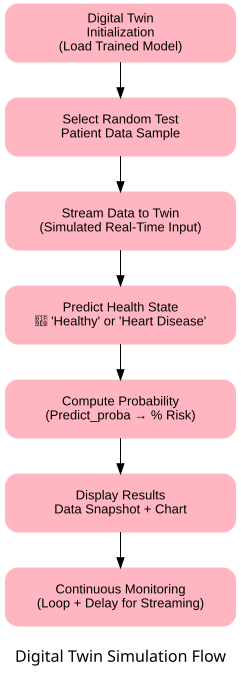

In [ ]:
from graphviz import Digraph

# =========================================================
# DIGITAL TWIN: SIMULATION WORKFLOW (Portrait View)
# =========================================================

twin = Digraph("Digital_Twin_Simulation_Workflow", format="png")

# Portrait layout (Top to Bottom)
twin.attr(rankdir='TB', size='8,14')
twin.attr('node',
          shape='box',
          style='rounded,filled',
          color='lightpink',
          fontname="Arial",
          fontsize='13',
          width='3.2',
          height='0.8')

# -----------------------------
# DIGITAL TWIN SIMULATION STAGES
# -----------------------------

twin.node("A", "Digital Twin\nInitialization\n(Load Trained Model)")
twin.node("B", "Select Random Test\nPatient Data Sample")
twin.node("C", "Stream Data to Twin\n(Simulated Real-Time Input)")
twin.node("D", "Predict Health State\n🧠 'Healthy' or 'Heart Disease'")
twin.node("E", "Compute Probability\n(Predict_proba → % Risk)")
twin.node("F", "Display Results\nData Snapshot + Chart")
twin.node("G", "Continuous Monitoring\n(Loop + Delay for Streaming)")

# -----------------------------
# CONNECTIONS
# -----------------------------
twin.edge("A", "B")
twin.edge("B", "C")
twin.edge("C", "D")
twin.edge("D", "E")
twin.edge("E", "F")
twin.edge("F", "G")

# -----------------------------
# LABEL & OUTPUT
# -----------------------------
twin.attr(label=r"\nDigital Twin Simulation Flow", fontsize='16', fontname="Arial Bold")

# Assign to f for rendering
f = twin
f


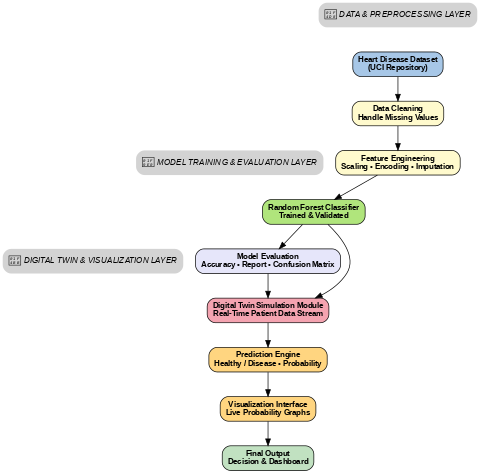

In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

# Create a portrait-style architecture diagram
concept_graph = Digraph("Heart_Disease_Digital_Twin_Architecture", format="png")
concept_graph.attr(rankdir='TB', size='5,8')
concept_graph.attr('node', shape='box', style='rounded,filled', fontname="Arial Bold", fontsize='11')

# --- Color palette by layer ---
data_color = "#A7C7E7"       # data layer
process_color = "#FFFACD"    # preprocessing
model_color = "#B0E57C"      # ML model
eval_color = "#E6E6FA"       # evaluation
twin_color = "#F4A3B0"       # digital twin
viz_color = "#FFD580"        # visualization
output_color = "#C1E1C1"     # final output

# --- Top Layer: Input / Data ---
concept_graph.node("data", "Heart Disease Dataset\n(UCI Repository)", fillcolor=data_color)

# --- Second Layer: Preprocessing ---
concept_graph.node("clean", "Data Cleaning\nHandle Missing Values", fillcolor=process_color)
concept_graph.node("prep", "Feature Engineering\nScaling • Encoding • Imputation", fillcolor=process_color)

# --- Middle Layer: Model Training & Evaluation ---
concept_graph.node("model", "Random Forest Classifier\nTrained & Validated", fillcolor=model_color)
concept_graph.node("eval", "Model Evaluation\nAccuracy • Report • Confusion Matrix", fillcolor=eval_color)

# --- Next Layer: Digital Twin System ---
concept_graph.node("twin", "Digital Twin Simulation Module\nReal-Time Patient Data Stream", fillcolor=twin_color)
concept_graph.node("predict", "Prediction Engine\nHealthy / Disease • Probability", fillcolor=viz_color)
concept_graph.node("visual", "Visualization Interface\nLive Probability Graphs", fillcolor=viz_color)

# --- Bottom Layer: Output ---
concept_graph.node("output", "Final Output\nDecision & Dashboard", fillcolor=output_color)

# --- Logical (non-linear) connections ---
concept_graph.edge("data", "clean")
concept_graph.edge("clean", "prep")
concept_graph.edge("prep", "model")
concept_graph.edge("model", "eval")
concept_graph.edge("model", "twin")
concept_graph.edge("eval", "twin")
concept_graph.edge("twin", "predict")
concept_graph.edge("predict", "visual")
concept_graph.edge("visual", "output")

# Optional cluster labels for layered grouping
concept_graph.attr('node', shape='plaintext', fontsize='12', fontname="Arial Italic")
concept_graph.node("lbl_data", "📘 DATA & PREPROCESSING LAYER")
concept_graph.node("lbl_model", "🧠 MODEL TRAINING & EVALUATION LAYER")
concept_graph.node("lbl_twin", "💻 DIGITAL TWIN & VISUALIZATION LAYER")

# Invisible edges for layer positioning
concept_graph.edge("lbl_data", "data", style="invis")
concept_graph.edge("lbl_model", "model", style="invis")
concept_graph.edge("lbl_twin", "twin", style="invis")

# Render & display
path = "/mnt/data/Portrait_Heart_Disease_Digital_Twin_Architecture"
concept_graph.render(path, cleanup=True)
display(Image(filename=f"{path}.png"))


In [ ]:
!apt-get install graphviz -y
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


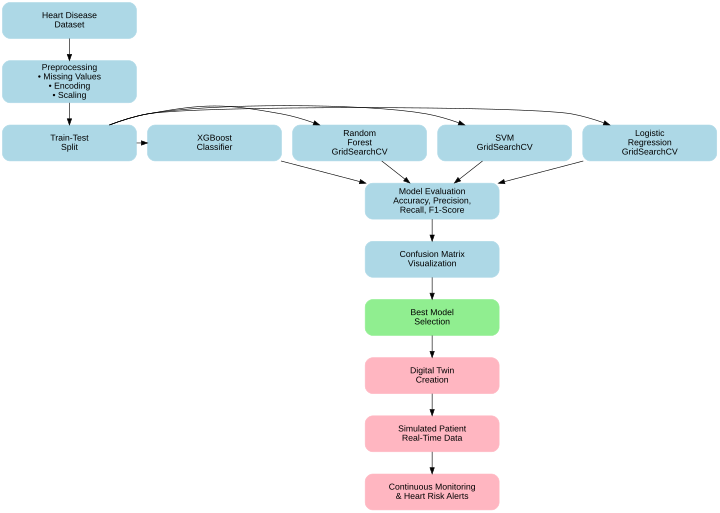

In [ ]:
from graphviz import Digraph

workflow = Digraph("Heart_Disease_Digital_Twin_Workflow", format="png")

# Portrait layout (Top to Bottom)
workflow.attr(rankdir='TB', size='10,20')  # T -> B (top to bottom)
workflow.attr('node',
              shape='box',
              style='rounded,filled',
              color='lightblue',
              fontname="Arial",
              fontsize='14',
              width='3',
              height='0.8')

# Core ML pipeline nodes
workflow.node("A", "Heart Disease\nDataset")
workflow.node("B", "Preprocessing\n• Missing Values\n• Encoding\n• Scaling")
workflow.node("C", "Train-Test\nSplit")

# Model training nodes
workflow.node("D1", "Logistic\nRegression\nGridSearchCV")
workflow.node("D2", "SVM\nGridSearchCV")
workflow.node("D3", "Random\nForest\nGridSearchCV")
workflow.node("D4", "XGBoost\nClassifier")

workflow.node("E", "Model Evaluation\nAccuracy, Precision,\nRecall, F1-Score")
workflow.node("F", "Confusion Matrix\nVisualization")

workflow.attr('node', color='lightgreen')
workflow.node("G", "Best Model\nSelection")

workflow.attr('node', color='lightpink')
workflow.node("H", "Digital Twin\nCreation")
workflow.node("I", "Simulated Patient\nReal-Time Data")
workflow.node("J", "Continuous Monitoring\n& Heart Risk Alerts")

# Connections (Top-down)
workflow.edge("A", "B")
workflow.edge("B", "C")

# Cluster the ML models side-by-side at the same rank
with workflow.subgraph() as s:
    s.attr(rank='same')
    s.edge("C", "D1")
    s.edge("C", "D2")
    s.edge("C", "D3")
    s.edge("C", "D4")

workflow.edge("D1", "E")
workflow.edge("D2", "E")
workflow.edge("D3", "E")
workflow.edge("D4", "E")

workflow.edge("E", "F")
workflow.edge("F", "G")
workflow.edge("G", "H")
workflow.edge("H", "I")
workflow.edge("I", "J")

workflow


In [ ]:
import joblib
from google.colab import files

# Save the trained pipeline
joblib.dump(dt_pipeline, 'digital_twin_rf.joblib')
print("💾 Model saved as 'digital_twin_rf.joblib'")

# Download the file to your local device
files.download('digital_twin_rf.joblib')
print("📥 Download started — check your browser downloads.")


💾 Model saved as 'digital_twin_rf.joblib'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started — check your browser downloads.


In [ ]:
import joblib
from google.colab import files

# Save the trained pipeline
joblib.dump(dt_pipeline, 'digital_twin_rf.joblib')

# Download the file to your local device
files.download('digital_twin_rf.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>